## Baseline Lock-In

In [36]:
import joblib 
import pandas as pd
from sklearn.model_selection import train_test_split

xgb_balanced = joblib.load("xgb_balanced.joblib")

df = pd.read_csv("cleaned_data.csv")

x = df.drop("default_payment_next_month", axis=1)
y = df["default_payment_next_month"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

y_pred = xgb_balanced.predict(x_test)
y_prob = xgb_balanced.predict_proba(x_test)[ : ,1]

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))
print(recall_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.79      0.84      4667
           1       0.46      0.63      0.53      1326

    accuracy                           0.76      5993
   macro avg       0.67      0.71      0.68      5993
weighted avg       0.79      0.76      0.77      5993

[[3699  968]
 [ 490  836]]
0.7751943865677338
0.6304675716440422


### What is minority recall?
- Minority Recall is 0.63 which is of 'defaulters" class because their sample size is 1326. Which shows 
- *out of all the actual defaulter how many did we predicted correctly*.
- Out of 100 defaulters our model predicted 63 of them correctly.

### What is precision?
- Precision of minority class is 0.46. Which shows 
- *out of all the predictions we made as positive how many were them actually positive*.
- Out of 100 instances model marked as defaulters 46 were actually defaulters.

### Which error type dominates?
- False Positive type error dominates due to low precision and high recall which is 968.

### Is threshold still 0.5 or optimized?
- Yes threshold is still default which is 0.5.

## Explicit Error Separation

In [38]:
result = x_test.copy()

result["true"] = y_test
result["pred"] = y_pred
result["prob"] = y_prob

false_pos = result[(result["true"] == 0) & (result["pred"] == 1)]
false_neg = result[(result["true"] == 1) & (result["pred"] == 0)]
true_pos  = result[(result["true"] == 1) & (result["pred"] == 1)]
true_neg  = result[(result["true"] == 0) & (result["pred"] == 0)]

In [39]:
false_pos.index.size, false_neg.index.size

(968, 490)

### Count FP vs FN.
- Their are 968 False Positive (FP) errors and 490 False Negative (FN) errors 

### Which is larger?
- Clearly False Positive error is in large quantity.

### Which is more costly in credit default context?
- False Negative is more costly because if you predict defaulter as Non-defaulter then that is direct loss in credit default context.

### Does imbalance explain the ratio?
- Although the dataset is imbalanced, the dominant error type (FP) is primarily driven by recall-focused tuning rather than imbalance alone.
- By optimizing for higher recall, the model shifts its decision boundary to classify more samples as positive, reducing FN but increasing FP.
- Therefore, the current error ratio reflects an intentional trade-off rather than a natural imbalance artifact.

## Probability-Based Error Inspection

In [40]:
result["confidence"] = abs(result["prob"] - 0.5)

confident_error = result[(result["true"] != result["pred"]) & (result["confidence"] > 0.3)]
borderline_error = result[(result["true"] != result["pred"]) & (result["confidence"] <= 0.3)]

In [41]:
confident_error.index.size, borderline_error.index.size

(268, 1190)

In [42]:
confident_error["true"].value_counts()

true
0    205
1     63
Name: count, dtype: int64

### Are most mistakes near decision boundary?
- Yes most mistakes are near the boundary. which means that model is good at predicting class probability.

### Are there highly confident wrong predictions?
- Yes their are 268 highly confident error. 
- In this confident mistakes models is making 205 False positives ans 63 False Negatives.

### If confident wrong → what does that imply?
- It implies that model made mistake with very high confidence or probability of false class (if true class was positive then model has given very high probability of negative class).

## Subgroup Performance Breakdown

In [43]:
result["age_bucket"] = pd.cut(result["age"], bins=[20,30,40,80])


print(result["age_bucket"].value_counts())

subgroup_metrics = result.groupby("age_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))

subgroup_metrics

age_bucket
(20, 30]    2202
(30, 40]    2112
(40, 80]    1679
Name: count, dtype: int64


C:\Users\taksh\AppData\Local\Temp\ipykernel_12696\99840607.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subgroup_metrics = result.groupby("age_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))
C:\Users\taksh\AppData\Local\Temp\ipykernel_12696\99840607.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subgroup_metrics = result.groupby("age_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))


age_bucket
(20, 30]    0.623431
(30, 40]    0.604119
(40, 80]    0.666667
dtype: float64

### Does recall drop in certain age ranges?
- Yes, recall drops in age group range of 30-40 but it is about 6% which is not marginal nor critical it is moderate though every bin has equal number of instances it cannot be due to sampling error.

### Does default prediction skew toward specific groups?
- Yes, recall is high in age group range of 40-80.

### Is performance uniform?
- No, model is predicting more defaulters in age group of 40-80 and is missing some in age group 30-40 this can be due to several reasons but we can interpret that model relies heavily on pay_1 of younger customers have paid their earlier bill but still defaults then model will not be able to predict that behavior.

In [44]:
result["pay_1_bucket"] = pd.cut(result["pay_1"], bins=[-3, -1, 0, 10])

print(result["pay_1_bucket"].value_counts())

subgroup_metrics = result.groupby("pay_1_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))

subgroup_metrics

pay_1_bucket
(-1, 0]     2917
(-3, -1]    1737
(0, 10]     1339
Name: count, dtype: int64


C:\Users\taksh\AppData\Local\Temp\ipykernel_12696\3898872046.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subgroup_metrics = result.groupby("pay_1_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))
C:\Users\taksh\AppData\Local\Temp\ipykernel_12696\3898872046.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subgroup_metrics = result.groupby("pay_1_bucket").apply(lambda df: recall_score(df["true"], df["pred"]))


pay_1_bucket
(-3, -1]    0.380228
(-1, 0]     0.237374
(0, 10]     0.962519
dtype: float64

## False Negative Investigation

In [45]:
false_neg.describe()

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,true,pred,prob
count,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,...,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.0,490.0,490.000000
mean,14454.463265,167551.020408,1.569388,1.889796,1.544898,35.646939,-0.381633,-0.467347,-0.395918,-0.440816,...,41478.506122,6035.006122,5453.216327,4196.932653,5875.226531,4964.393878,5720.344898,1.0,0.0,0.325323
std,8852.019762,128144.387701,0.495668,0.796271,0.530293,9.295415,0.742563,0.751246,0.857055,0.846965,...,65574.091010,14175.044042,15785.139579,7315.092268,22346.338283,18965.476562,17506.520365,0.0,0.0,0.105650
min,27.000000,10000.000000,1.000000,1.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-94625.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.033699
25%,6749.750000,60000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1414.250000,1357.500000,1133.000000,625.500000,500.000000,391.000000,500.000000,1.0,0.0,0.255330
50%,14116.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,15440.000000,2391.500000,2089.500000,2000.000000,1875.500000,1774.000000,2000.000000,1.0,0.0,0.336850
75%,22248.500000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,50356.750000,5442.500000,5005.250000,4495.250000,4540.250000,4230.250000,4979.750000,1.0,0.0,0.408385
max,30000.000000,630000.000000,2.000000,6.000000,3.000000,66.000000,2.000000,2.000000,3.000000,2.000000,...,472480.000000,175100.000000,255005.000000,65825.000000,432130.000000,330982.000000,200655.000000,1.0,0.0,0.499614


In [46]:
pd.cut(false_neg["prob"], bins=[0, 0.2, 0.3, 0.51]).value_counts()

prob
(0.3, 0.51]    302
(0.2, 0.3]     125
(0.0, 0.2]      63
Name: count, dtype: int64

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'limit_bal'}>,
        <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'marriage'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'pay_1'}>,
        <Axes: title={'center': 'pay_2'}>,
        <Axes: title={'center': 'pay_3'}>,
        <Axes: title={'center': 'pay_4'}>],
       [<Axes: title={'center': 'pay_5'}>,
        <Axes: title={'center': 'pay_6'}>,
        <Axes: title={'center': 'bill_amt1'}>,
        <Axes: title={'center': 'bill_amt2'}>,
        <Axes: title={'center': 'bill_amt3'}>],
       [<Axes: title={'center': 'bill_amt4'}>,
        <Axes: title={'center': 'bill_amt5'}>,
        <Axes: title={'center': 'bill_amt6'}>,
        <Axes: title={'center': 'pay_amt1'}>,
        <Axes: title={'center': 'pay_amt2'}>],
       [<Axes: title={'center': 'pay_amt3'}>,
        <Axes: title={'center': 'pay_amt4'}>,
        <A

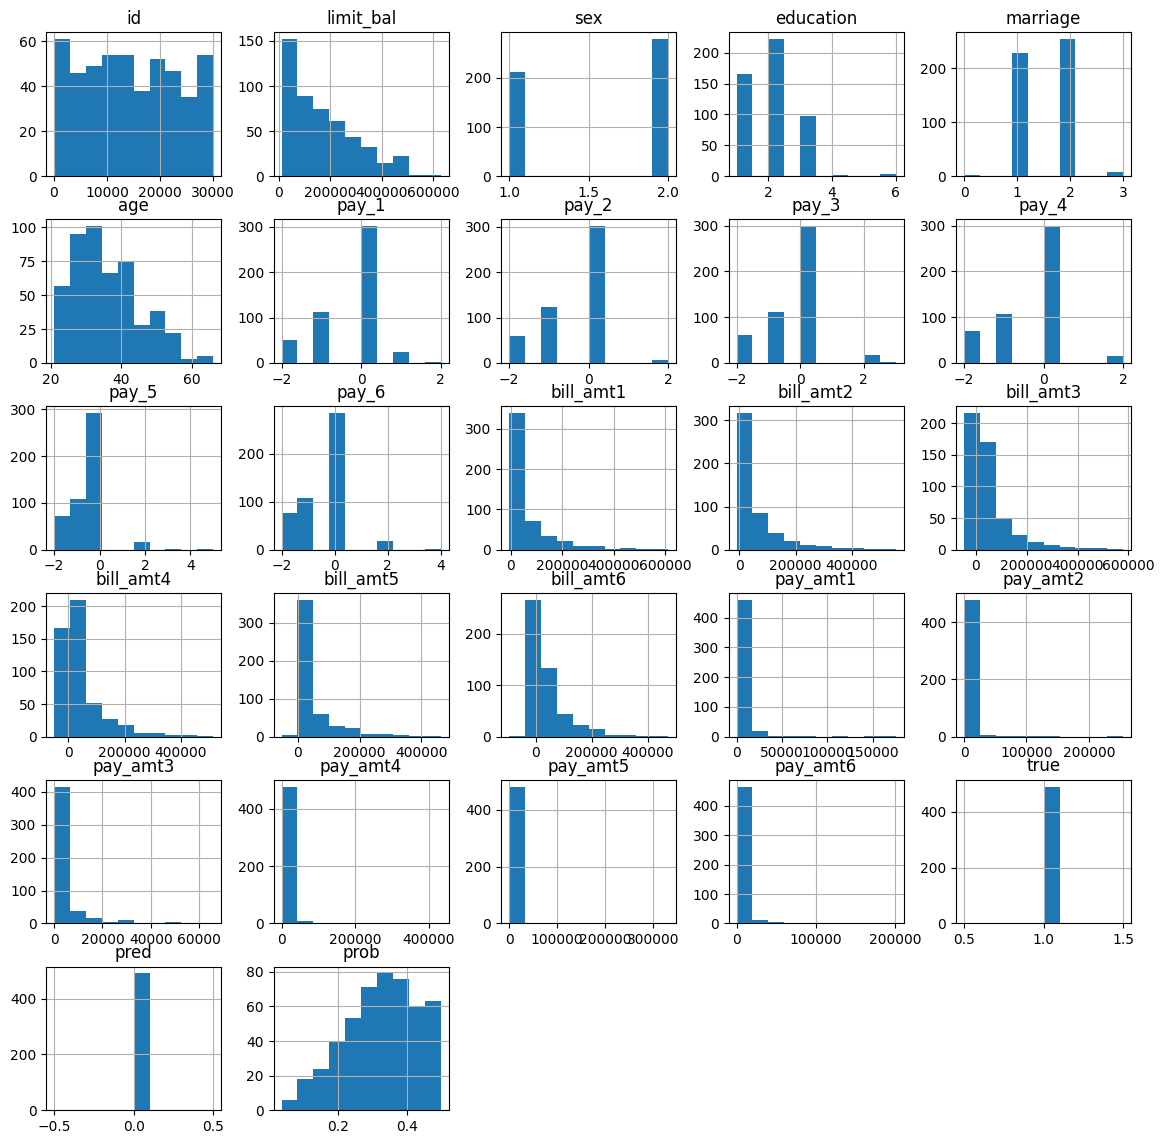

In [47]:
false_neg.hist(figsize=(14,14))

In [48]:
true_pos.describe()

,id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,true,pred,prob
count,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,...,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.0,836.0,836.000000
mean,14809.154306,112081.339713,1.571770,1.965311,1.488038,36.545455,1.260766,0.984450,0.846890,0.710526,...,37849.991627,2277.163876,2283.279904,2430.727273,2150.029904,2076.717703,2311.244019,1.0,1.0,0.778936
std,8476.232963,105264.869625,0.495118,0.686913,0.516646,10.309421,1.357681,1.579357,1.653304,1.715009,...,55696.016404,5123.907880,5261.136824,7538.382643,7170.034395,4446.028833,8337.234765,0.0,0.0,0.142006
min,2.000000,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-3827.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.500043
25%,7788.500000,30000.000000,1.000000,1.750000,1.000000,28.000000,1.000000,0.000000,0.000000,0.000000,...,2087.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.657834
50%,14738.000000,80000.000000,2.000000,2.000000,1.000000,35.000000,2.000000,2.000000,2.000000,0.000000,...,19264.500000,1304.500000,1300.000000,1000.000000,790.000000,909.500000,622.500000,1.0,1.0,0.814684
75%,21553.000000,150000.000000,2.000000,2.000000,2.000000,44.000000,2.000000,2.000000,2.000000,2.000000,...,47614.250000,2854.750000,2907.250000,2494.000000,2000.000000,2318.750000,2000.000000,1.0,1.0,0.907312
max,29974.000000,580000.000000,2.000000,5.000000,3.000000,73.000000,8.000000,7.000000,7.000000,7.000000,...,498316.000000,105200.000000,120018.000000,167622.000000,138355.000000,86728.000000,158064.000000,1.0,1.0,0.969762


### Are FN cases lower credit utilization?
- No, in fact they have higher credit utilization both in terms of credit spend and limit balance.

### Are they edge profiles?
- Yes, The majority of false negatives occur near the decision boundary, with most prediction probabilities falling between 0.3 and 0.51. This suggests the model is often uncertain rather than confidently incorrect. Such boundary errors typically arise when feature signals separating defaulters and non-defaulters overlap. A smaller subset of FN cases have very low predicted probabilities (<0.2), representing confident errors where the model strongly predicts non-default.

### Do they cluster around specific repayment history patterns?
- Yes, `pay_x` which shows payment delay since most false negatives has their payment or time or even early (-2, -1, 0) model thinks they are safe and also according to SHAP value model relies heavily on this pay status which explains why it is predicting them as non-defaulter while they are defaulters.

## Feature Distribution Comparison

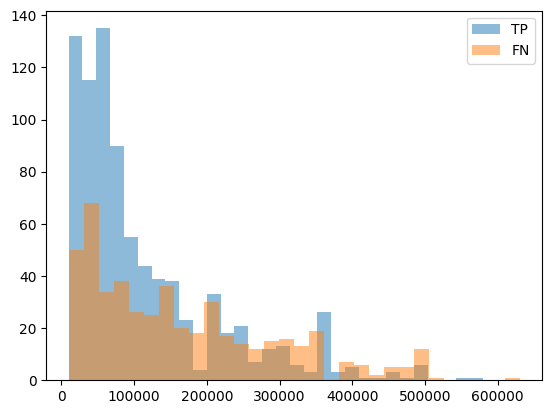

In [49]:
import matplotlib.pyplot as plt

plt.hist(true_pos["limit_bal"], bins=30, alpha=0.5)
plt.hist(false_neg["limit_bal"], bins=30, alpha=0.5)
plt.legend(["TP", "FN"])
plt.show()

### Do distributions overlap heavily? and Is there a region underrepresented in training?
- The distributions of LIMIT_BAL for true positives and false negatives overlap significantly, particularly in the lower and mid credit-limit ranges (0–200k). This indicates that credit limit alone does not strongly separate correctly detected defaulters from missed ones. Additionally, the higher credit-limit region (>400k) appears sparsely populated, suggesting that the model has limited training examples in this range, which may reduce prediction reliability for such customers.

## Hypothesis Formation

### Heavy Reliance on `pay_X`
- Model heavily relies on `pay_x` which leads to hallucination such as if customer does not delay payment then they are non-defaulter.

### Less Recall in age group 30-40
- Model is not able to correctly predict in age range 30-40 this can be due to may reasons such less stable lifestyle or high limit balance while paying on time. 